# Fitting dwell-time distributions

A focused notebook demonstrating MLE fitting of exponential mixtures, parameter
uncertainty quantification, and likelihood interval calculation, using a small
test dataset (`tests/intervals.txt`).

**Contents**
1. Load data
2. Fit two-component exponential PDF
3. Plot histogram with fitted curve
4. Critical time between components
5. Approximate SDs and correlation matrix
6. Likelihood intervals (2-unit drop)
7. Gaussian mixture PDF (amplitude data example)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from ekdist import (
    ExponentialPDF,
    GaussianMixturePDF,
    ApproximateSD,
    LikelihoodIntervals,
    plots,
)

---
## 1. Load data

In [2]:
intervals = np.loadtxt("tests/intervals.txt")
tres = 1e-4   # 100 uss dead-time resolution

print(f"Number of intervals : {len(intervals):,}")
print(f"Min / max           : {intervals.min():.4f}  /  {intervals.max():.4f} s")
print(f"Mean                : {intervals.mean():.4f} s")

Number of intervals : 125
Min / max           : 0.0011  /  5.2663 s
Mean                : 0.8400 s


---
## 2. Fit two-component exponential PDF

`ExponentialPDF` accepts initial time constants in seconds.  Calling `.fit()`
runs Nelder-Mead optimisation on the truncated negative log-likelihood.

In [3]:
pdf = ExponentialPDF([0.036, 1.1])   # two-component; initial tau guesses
pdf.fit(intervals, tres=tres)
print(pdf)

In [4]:
print(f"tau  (s) : {pdf.tau}")
print(f"area     : {pdf.area}")
print(f"tau (ms) : {pdf.tau * 1e3}")

tau  (s) : [0.03879784 1.07426044]
area     : [0.19489508 0.80510492]
tau (ms) : [  38.79783909 1074.26043528]


---
## 3. Dwell-time histogram with fitted curve

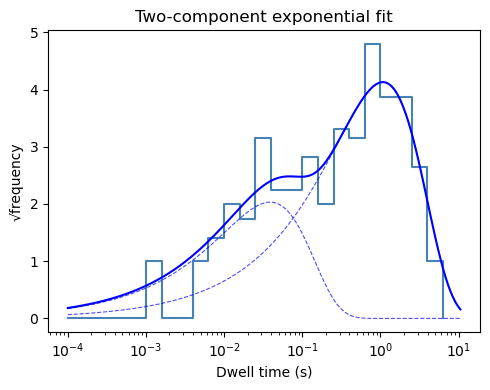

In [5]:
fig = plots.histogram_dwell_times(
    intervals, tres=tres, pdf=pdf,
    xlabel="Dwell time (s)",
    title="Two-component exponential fit",
)
plt.tight_layout()

---
## 4. Critical time between components

Three criteria are available:
- **DC** - equal percentage misclassified (Colquhoun & Sigworth)
- **C&N** - equal number misclassified (Clapham & Neher)
- **Jackson** - minimum total misclassified

In [6]:
pdf.get_tcrits(verbose=True)

Equal % misclassified (DC criterion)
Components 1–2  tcrit = 95.58 ms
  % misclassified: fast = 8.513  slow = 8.513
  # misclassified (per 100): fast = 1.659  slow = 6.854
  Total misclassified (per 100) = 8.513

Equal # misclassified (Clapham & Neher criterion)
Components 1–2  tcrit = 58.76 ms
  % misclassified: fast = 21.99  slow = 5.323
  # misclassified (per 100): fast = 4.286  slow = 4.286
  Total misclassified (per 100) = 8.571

Minimum total # misclassified (Jackson et al criterion)
Components 1–2  tcrit = 76.58 ms
  % misclassified: fast = 13.89  slow = 6.88
  # misclassified (per 100): fast = 2.708  slow = 5.539
  Total misclassified (per 100) = 8.247


SUMMARY of tcrit values (ms)
Components		DC		C&N		Jackson
1 to 2			95.58		58.76		76.58


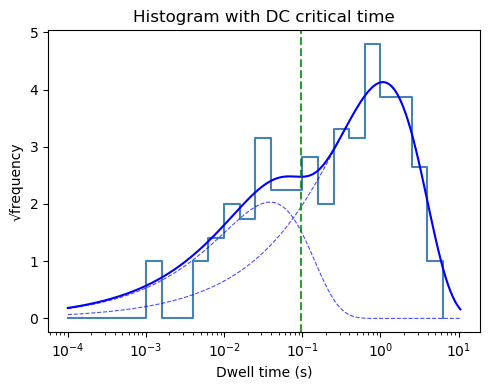

In [7]:
# Plot histogram with tcrit lines marked
fig = plots.histogram_dwell_times(
    intervals, tres=tres, pdf=pdf,
    tcrits=pdf.tcrits["DC"],
    xlabel="Dwell time (s)",
    title="Histogram with DC critical time",
)
plt.tight_layout()

---
## 5. Parameter uncertainty - approximate SDs

`ApproximateSD` numerically differentiates the log-likelihood surface at the
maximum to obtain the Hessian and hence the covariance matrix.

In [8]:
asd = ApproximateSD(pdf.theta, pdf.LL, intervals)

print("Hessian:")
print(np.round(asd.hessian, 2))
print()
print("Covariance matrix:")
print(np.round(asd.covariance, 6))
print()
print("Approximate SDs:")
for name, val, sd in zip(
    ["tau_1", "tau_2", "area_1"],
    pdf.theta,
    asd.sd,
):
    print(f"  {name} = {val:.4f}  +/-  {sd:.4f}")

Hessian:
[[8002.39  -81.73 -651.49]
 [ -81.73   71.18  -37.55]
 [-651.49  -37.55  509.22]]

Covariance matrix:
[[0.000144 0.000274 0.000205]
 [0.000274 0.015137 0.001467]
 [0.000205 0.001467 0.002334]]

Approximate SDs:
  tau_1 = 0.0388  +/-  0.0120
  tau_2 = 0.8543  +/-  0.1230
  area_1 = 0.1550  +/-  0.0483


In [9]:
print("Correlation matrix:")
print(np.round(asd.correlations, 3))

Correlation matrix:
[[1.    0.185 0.353]
 [0.185 1.    0.247]
 [0.353 0.247 1.   ]]


---
## 6. Likelihood intervals

Likelihood intervals are asymmetric and more reliable than Gaussian SDs,
especially near parameter boundaries.  A 2-unit drop from the maximum
log-likelihood corresponds roughly to +/-2 SD.

In [10]:
m = 2.0   # log-likelihood drop threshold

likints = LikelihoodIntervals(pdf.theta, pdf, intervals, asd.sd, m)
intervals_table = likints.calculate()

print("\nLikelihood intervals (m = 2.0):")
labels = ["tau_1 (s)", "tau_2 (s)", "area_1"]
for label, (lo, hi), val in zip(labels, intervals_table, pdf.theta):
    print(f"  {label:12s}  {lo:.5f} < {val:.5f} < {hi:.5f}")


Likelihood intervals (m = 2.0):
  tau_1 (s)     0.01481 < 0.03880 < 0.10500
  tau_2 (s)     0.78168 < 0.85425 < 1.59678
  area_1        0.07113 < 0.15498 < 0.34937


---
## 7. Gaussian mixture PDF - amplitude histogram

`GaussianMixturePDF` fits single-channel amplitude histograms.  Here we
generate a synthetic two-component amplitude dataset to illustrate the API.

In [11]:
rng = np.random.default_rng(0)

# Synthetic amplitudes: 70% at 5.5 pA, 30% at 3.0 pA (subconductance)
amps = np.concatenate([
    rng.normal(5.5, 0.15, 700),
    rng.normal(3.0, 0.20, 300),
])

print(f"Total amplitudes: {len(amps)}")
print(f"Range: {amps.min():.2f} - {amps.max():.2f} pA")

Total amplitudes: 1000
Range: 2.41 - 5.96 pA


In [12]:
# Two-component Gaussian mixture
# Provide initial guesses matching the synthetic data centres
gpdf = GaussianMixturePDF(means=[5.5, 3.0], sigmas=[0.2, 0.2])
gpdf.fit(amps)
print(gpdf)

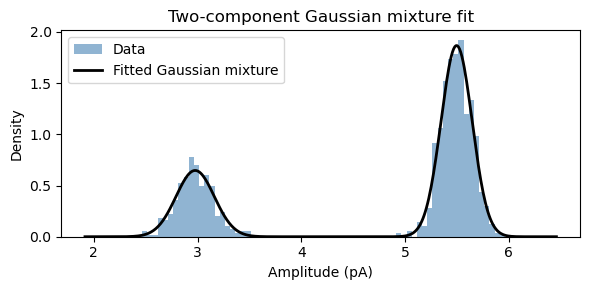

In [13]:
# Manual plot (histogram_dwell_times is for exponential / log-axis data)
x = np.linspace(amps.min() - 0.5, amps.max() + 0.5, 400)
y = gpdf.pdf(gpdf.theta, x)

fig, ax = plt.subplots(figsize=(6, 3))
bw = 0.05
bins = np.arange(amps.min(), amps.max() + bw, bw)
ax.hist(amps, bins=bins, density=True, color="steelblue",
        alpha=0.6, label="Data")
ax.plot(x, y, "k-", lw=2, label="Fitted Gaussian mixture")
ax.set_xlabel("Amplitude (pA)")
ax.set_ylabel("Density")
ax.set_title("Two-component Gaussian mixture fit")
ax.legend()
plt.tight_layout()

In [14]:
print(f"Component 1: mean = {gpdf.means[0]:.3f} pA,  sigma = {gpdf.sigmas[0]:.3f} pA,  "
      f"area = {gpdf.areas[0]:.3f}")
print(f"Component 2: mean = {gpdf.means[1]:.3f} pA,  sigma = {gpdf.sigmas[1]:.3f} pA,  "
      f"area = {gpdf.areas[1]:.3f}")

Component 1: mean = 5.497 pA,  sigma = 0.150 pA,  area = 0.700
Component 2: mean = 2.977 pA,  sigma = 0.185 pA,  area = 0.300
